# Prediksi Kualitas Wine Menggunakan Machine Learning

**Mata Kuliah:** Data Mining  

**Nama Mahasiswa:** Ahmad Faisal Majid

**NIM:** 2304020027

**Dosen Pengampu:** Nur Achmey Selgi Harwanti S.Stat., M.Stat

---

## Projek UTS

Projek UTS ini bertujuan selain sebagai bukti menyelesaikan UTS namun juga untuk membangun model klasifikasi yang dapat memprediksi kualitas wine berdasarkan karakteristik kimiawi. Dataset training digunakan untuk melatih dan mengevaluasi model, sedangkan dataset testing digunakan untuk menghasilkan prediksi akhir.




## 1. Persiapan Library

Pada tahap ini dilakukan pemanggilan library yang dibutuhkan untuk proses analisis data, visualisasi, preprocessing, pemodelan, dan evaluasi. Library yang digunakan meliputi `pandas`, `numpy`, `matplotlib`, `seaborn`, serta beberapa modul dari `scikit-learn`.

Random Forest dipilih karena mampu menangani data tabular dengan baik, relatif stabil terhadap outlier, dan dapat memberikan informasi tambahan berupa tingkat kepentingan fitur atau *feature importance*.

In [97]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Dataset

Dataset training dan testing diunggah secara manual melalui Google Colab. Dataset training digunakan untuk membangun model karena memiliki kolom target `quality`, sedangkan dataset testing tidak memiliki label target dan akan digunakan untuk prediksi akhir.

Pastikan file yang diunggah bernama:

- `data_training.csv`
- `data_testing.csv`

In [98]:
# Upload file
from google.colab import files
uploaded = files.upload()

# Load dataset
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

Saving data_testing.csv to data_testing (2).csv
Saving data_training.csv to data_training (2).csv


## 3. Pemeriksaan Struktur Awal Dataset

Pemeriksaan awal dilakukan untuk memahami ukuran dataset, nama kolom, dan beberapa baris pertama data. Tahap ini penting agar struktur data dapat dipastikan sudah sesuai sebelum dilakukan pemodelan.

In [99]:
# Melihat ukuran dataset
print("Ukuran data training:", train.shape)
print("Ukuran data testing :", test.shape)

# Melihat nama kolom
print("\nKolom data training:")
print(train.columns.tolist())

print("\nKolom data testing:")
print(test.columns.tolist())

Ukuran data training: (857, 13)
Ukuran data testing : (286, 12)

Kolom data training:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']

Kolom data testing:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'Id']


In [100]:
# Menampilkan lima baris pertama data training
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


### Interpretasi Awal

Data training memuat variabel-variabel kimiawi wine seperti kadar alkohol, keasaman, pH, sulfat, klorida, dan variabel lain yang relevan. Kolom `quality` digunakan sebagai target klasifikasi, sedangkan kolom `Id` hanya berfungsi sebagai identitas observasi sehingga tidak digunakan sebagai fitur model.

In [101]:
# Informasi struktur data training
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Output `train.info()` digunakan untuk melihat jumlah baris, jumlah kolom, tipe data, dan jumlah data non-null. Informasi ini membantu memastikan apakah terdapat kolom dengan tipe data yang tidak sesuai atau nilai kosong yang perlu ditangani.

In [102]:
# Statistik deskriptif data numerik
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Statistik deskriptif memberikan gambaran umum mengenai nilai rata-rata, standar deviasi, nilai minimum, kuartil, dan nilai maksimum pada setiap variabel numerik. Informasi ini berguna untuk melihat rentang nilai antarfitur dan mendeteksi kemungkinan nilai ekstrem.

## 4. Pemeriksaan Missing Value

Sebelum membangun model, perlu dipastikan bahwa dataset tidak mengandung missing value. Missing value dapat menyebabkan error pada proses training model atau menurunkan kualitas prediksi apabila tidak ditangani dengan tepat.

In [103]:
# Cek missing value pada data training
missing_values = train.isnull().sum()
missing_values

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


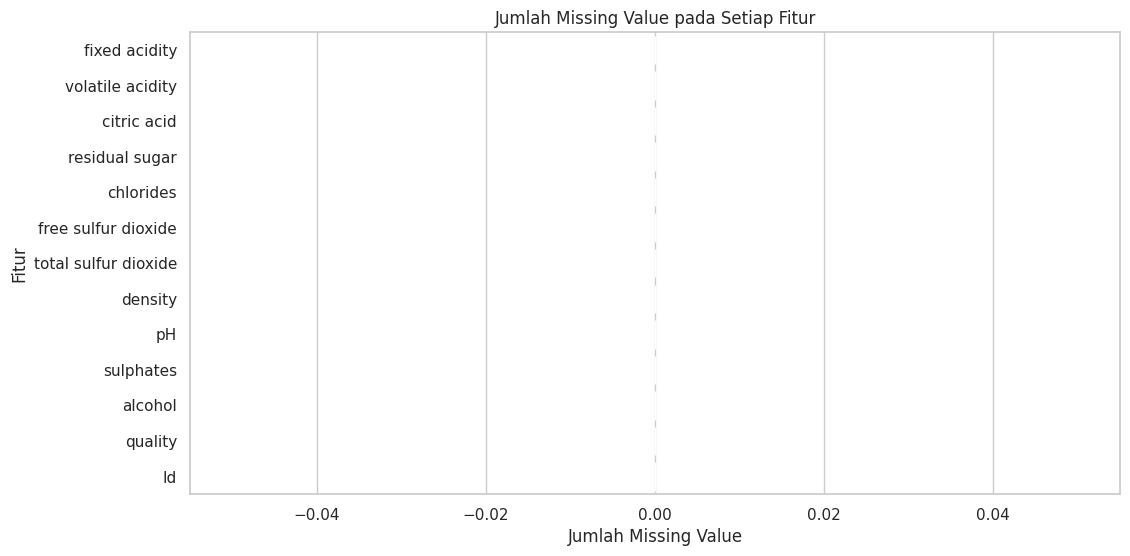

In [104]:
# Visualisasi missing value
missing_df = missing_values.reset_index()
missing_df.columns = ["Fitur", "Jumlah Missing Value"]

plt.figure(figsize=(12, 6))
sns.barplot(data=missing_df, x="Jumlah Missing Value", y="Fitur")
plt.title("Jumlah Missing Value pada Setiap Fitur")
plt.xlabel("Jumlah Missing Value")
plt.ylabel("Fitur")
plt.show()

### Interpretasi Missing Value

Jika seluruh nilai pada hasil pemeriksaan bernilai 0, maka dataset tidak memiliki missing value. Artinya, tidak diperlukan proses imputasi atau penghapusan data. Apabila pada dataset lain ditemukan missing value, penanganan yang dapat dilakukan antara lain imputasi menggunakan mean, median, modus, atau penghapusan baris/kolom tergantung karakteristik datanya.

## 5. Eksplorasi Distribusi Target

Variabel target dalam penelitian ini adalah `quality`. Pemeriksaan distribusi target penting dilakukan untuk mengetahui apakah data memiliki ketidakseimbangan kelas (*class imbalance*). Jika beberapa kelas memiliki jumlah observasi yang jauh lebih besar, model cenderung lebih mudah memprediksi kelas mayoritas dibandingkan kelas minoritas.

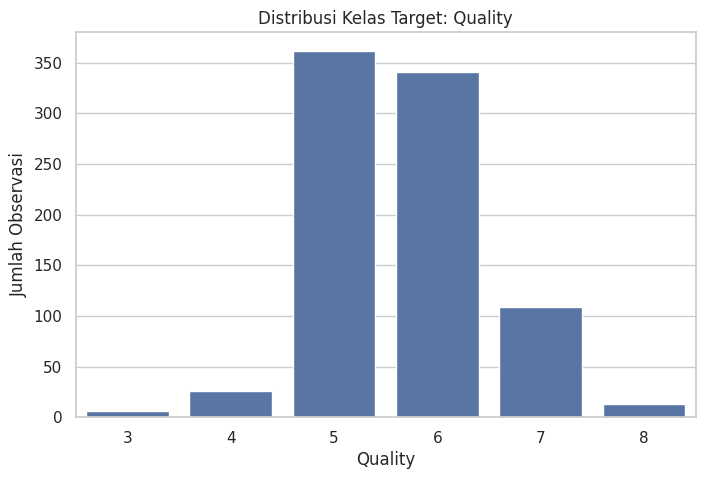

,count
quality,
3,6
4,26
5,362
6,341
7,109
8,13


In [105]:
# Distribusi target quality
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=train)
plt.title("Distribusi Kelas Target: Quality")
plt.xlabel("Quality")
plt.ylabel("Jumlah Observasi")
plt.show()

# Tabel frekuensi target
train['quality'].value_counts().sort_index()

### Interpretasi Distribusi Target

Distribusi kelas `quality` menunjukkan jumlah sampel pada setiap kategori kualitas wine. Apabila kelas tertentu seperti kualitas 5 atau 6 mendominasi, maka model berpotensi lebih akurat pada kelas tersebut, tetapi kurang baik dalam mengenali kelas yang jumlahnya lebih sedikit. Hal ini perlu diperhatikan saat membaca hasil confusion matrix dan classification report.

## 6. Analisis Korelasi Antarvariabel

Analisis korelasi digunakan untuk melihat hubungan linear antarvariabel numerik. Nilai korelasi mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan nilai mendekati -1 menunjukkan hubungan negatif yang kuat. Korelasi dengan `quality` dapat memberikan indikasi awal fitur mana yang cenderung berhubungan dengan kualitas wine.

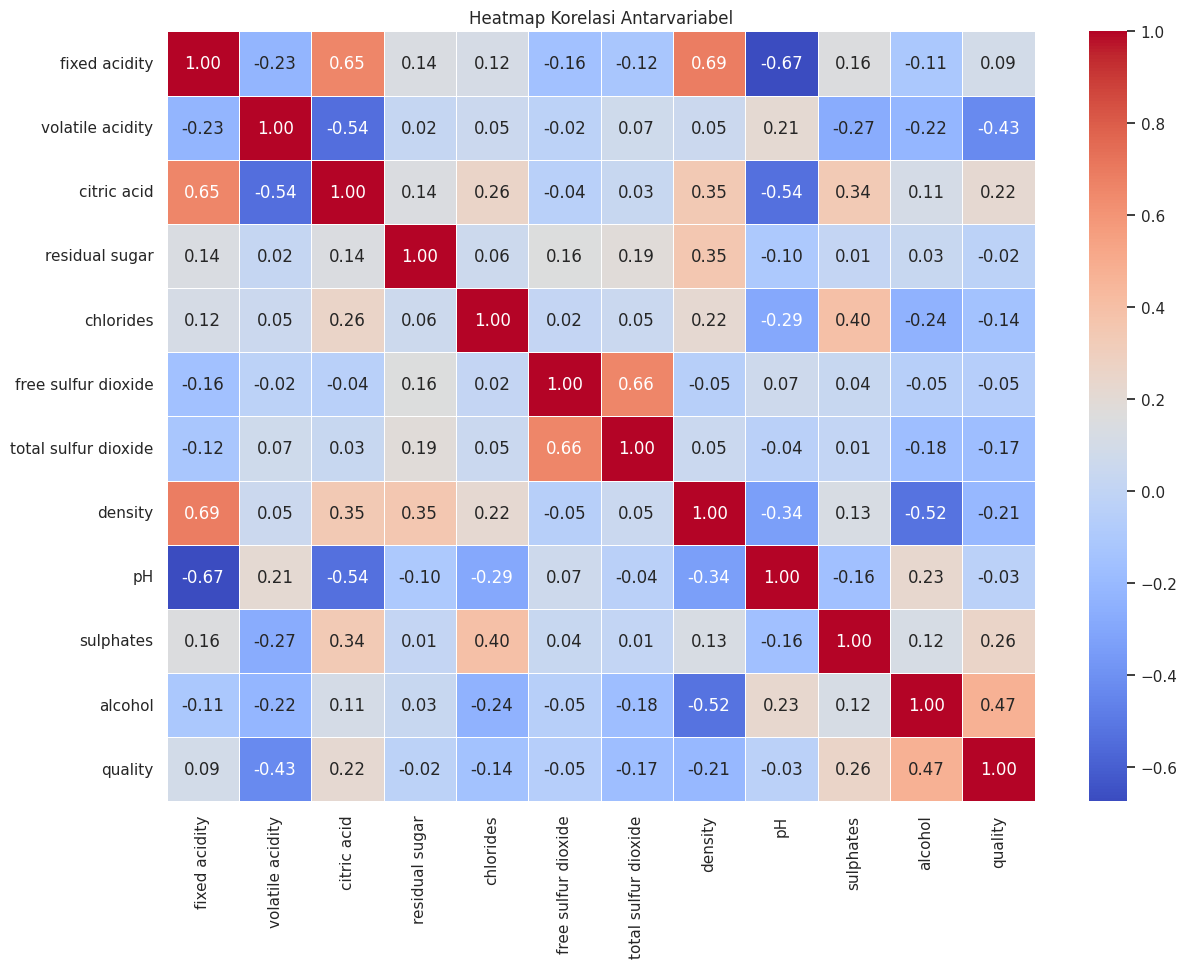

In [106]:
# Heatmap korelasi
plt.figure(figsize=(14, 10))
corr_matrix = train.drop(columns=['Id'], errors='ignore').corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Heatmap Korelasi Antarvariabel")
plt.show()

### Interpretasi Korelasi

Heatmap korelasi membantu mengidentifikasi fitur yang memiliki hubungan relatif kuat dengan `quality`. Pada dataset wine, fitur seperti `alcohol` sering menunjukkan hubungan positif terhadap kualitas, sedangkan beberapa variabel keasaman dapat memiliki hubungan negatif. Namun, korelasi tidak selalu berarti sebab-akibat, sehingga hasil ini digunakan sebagai pemahaman awal, bukan dasar tunggal pengambilan keputusan model.

## 7. Visualisasi Hubungan Fitur dengan Quality

Selain korelasi, hubungan antara beberapa fitur penting dan target `quality` dapat dilihat melalui boxplot. Visualisasi ini membantu memahami perbedaan distribusi nilai fitur pada setiap kelas kualitas wine.

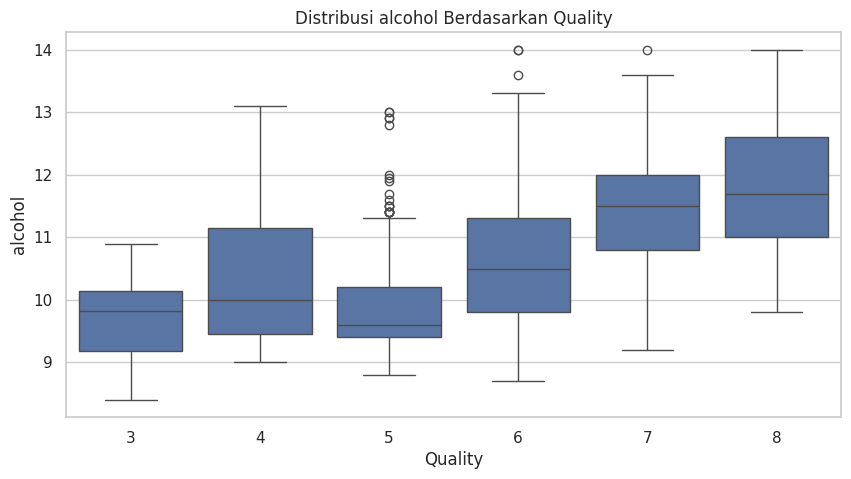

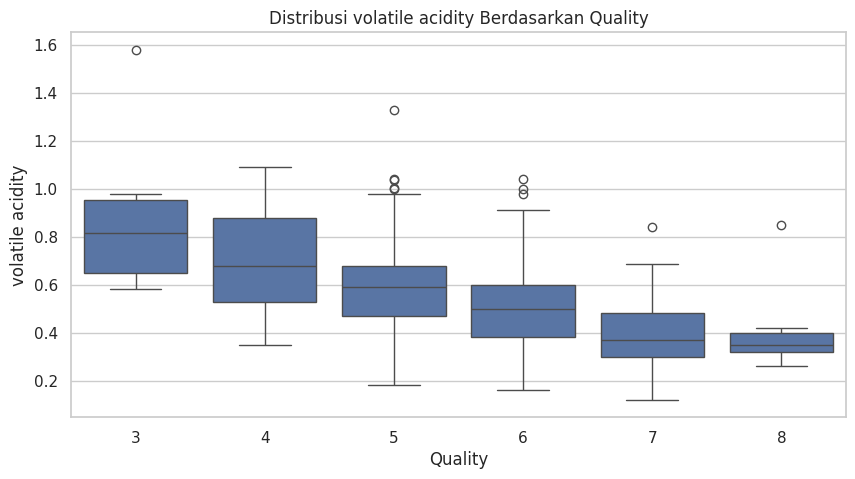

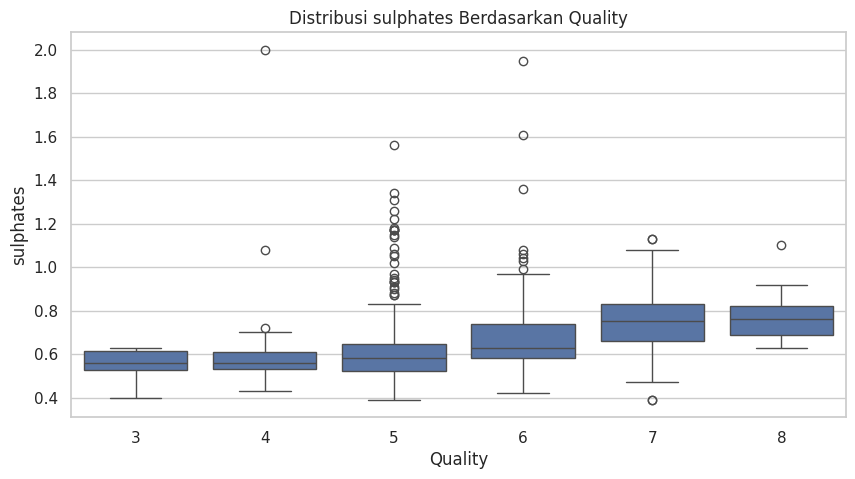

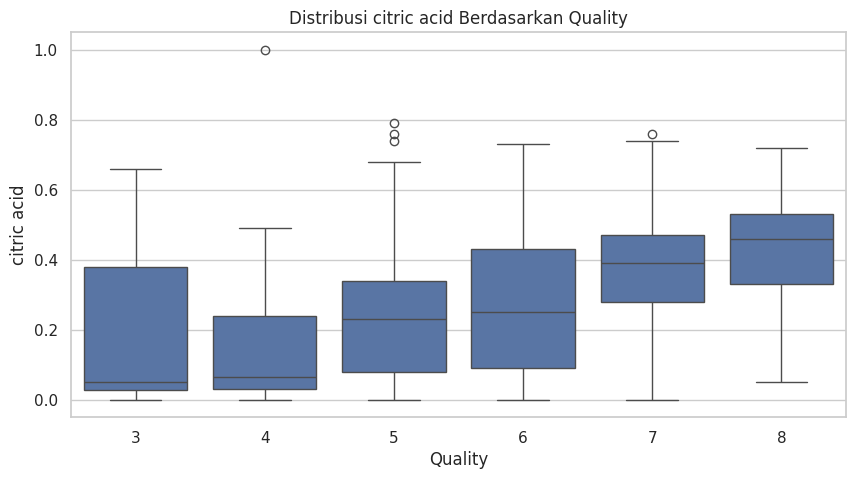

In [107]:
# Boxplot fitur penting terhadap quality
selected_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

for feature in selected_features:
    if feature in train.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=train, x='quality', y=feature)
        plt.title(f"Distribusi {feature} Berdasarkan Quality")
        plt.xlabel("Quality")
        plt.ylabel(feature)
        plt.show()

### Interpretasi Boxplot

Boxplot memperlihatkan median, variasi, serta kemungkinan outlier pada setiap fitur berdasarkan kelas `quality`. Apabila median suatu fitur meningkat atau menurun secara konsisten pada kelas kualitas yang lebih tinggi, fitur tersebut berpotensi memiliki kontribusi dalam membedakan kualitas wine.

## 8. Pemisahan Fitur dan Target

Pada tahap ini, dataset dipisahkan menjadi variabel prediktor `X` dan variabel target `y`. Kolom `quality` digunakan sebagai target, sedangkan kolom `Id` dihapus karena hanya merupakan identitas data dan tidak merepresentasikan karakteristik kimiawi wine.

> Bagian ini dipertahankan sesuai notebook awal agar hasil prediksi tetap sama.

In [108]:
X = train.drop(['quality', 'Id'], axis=1)
y = train['quality']

## 9. Pembagian Data Training dan Validasi

Data training dibagi menjadi data latih dan data validasi. Data latih digunakan untuk membangun model, sedangkan data validasi digunakan untuk mengevaluasi performa model sebelum diterapkan pada data testing.

Parameter `test_size=0.2` berarti 20% data digunakan sebagai validasi, sedangkan 80% digunakan untuk pelatihan. Nilai `random_state=42` dipertahankan agar hasil pembagian data konsisten dan dapat direproduksi.

In [109]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 10. Feature Scaling

Feature scaling dilakukan menggunakan `StandardScaler`. Proses ini mengubah skala fitur agar memiliki rata-rata 0 dan standar deviasi 1. Scaling dilakukan dengan prinsip yang benar: `fit_transform` hanya pada data latih, sedangkan data validasi menggunakan `transform` berdasarkan parameter dari data latih. Hal ini dilakukan untuk menghindari *data leakage*.

In [110]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

## 11. Pembuatan Model Random Forest

Model yang digunakan adalah `RandomForestClassifier` dengan 100 pohon keputusan. Random Forest bekerja dengan membangun banyak decision tree dan menggabungkan hasilnya untuk menghasilkan prediksi yang lebih stabil.

> Parameter `n_estimators=100` dan `random_state=42` dipertahankan sesuai notebook awal agar hasil prediksi tidak berubah.

In [111]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## 12. Evaluasi Model pada Data Validasi

Evaluasi dilakukan menggunakan akurasi, confusion matrix, dan classification report. Akurasi menunjukkan proporsi prediksi benar secara keseluruhan, sedangkan confusion matrix memperlihatkan pola kesalahan prediksi antar kelas. Classification report memberikan informasi lebih rinci berupa precision, recall, dan f1-score.

Accuracy: 0.5813953488372093


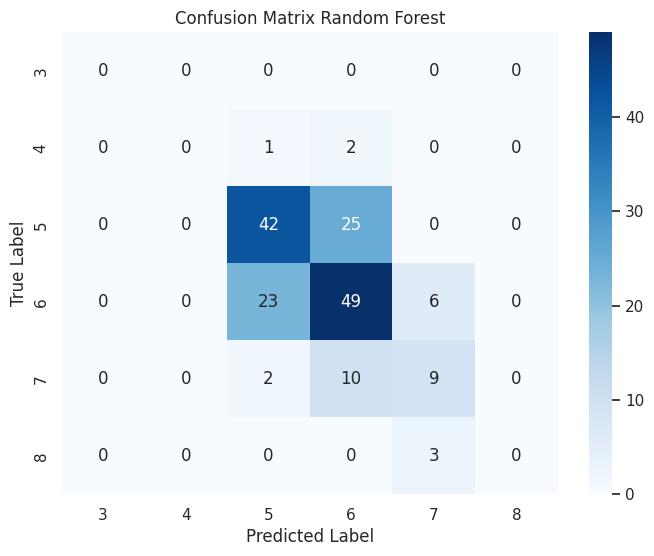

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.62      0.63      0.62        67
           6       0.57      0.63      0.60        78
           7       0.50      0.43      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.58       172
   macro avg       0.34      0.34      0.34       172
weighted avg       0.56      0.58      0.57       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [112]:
y_pred = model.predict(X_val)

# Akurasi
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
labels = np.sort(y.unique())
cm = confusion_matrix(y_val, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Random Forest")
plt.show()

# Classification Report
print(classification_report(y_val, y_pred))

### Interpretasi Evaluasi Model

Confusion matrix menunjukkan jumlah prediksi benar dan salah pada setiap kelas. Nilai pada diagonal utama menunjukkan prediksi yang benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi. Pada dataset kualitas wine, kesalahan sering terjadi pada kelas yang berdekatan, misalnya antara kualitas 5 dan 6, karena karakteristik kimiawinya dapat saling mirip.

Akurasi digunakan sebagai ukuran umum performa model. Namun, apabila distribusi kelas tidak seimbang, metrik seperti precision, recall, dan f1-score juga perlu diperhatikan agar evaluasi tidak hanya berpihak pada kelas mayoritas.

## 13. Feature Importance

Random Forest dapat memberikan informasi mengenai kontribusi relatif setiap fitur terhadap proses prediksi. Feature importance membantu memahami fitur mana yang paling berperan dalam membedakan kualitas wine berdasarkan model yang telah dilatih.

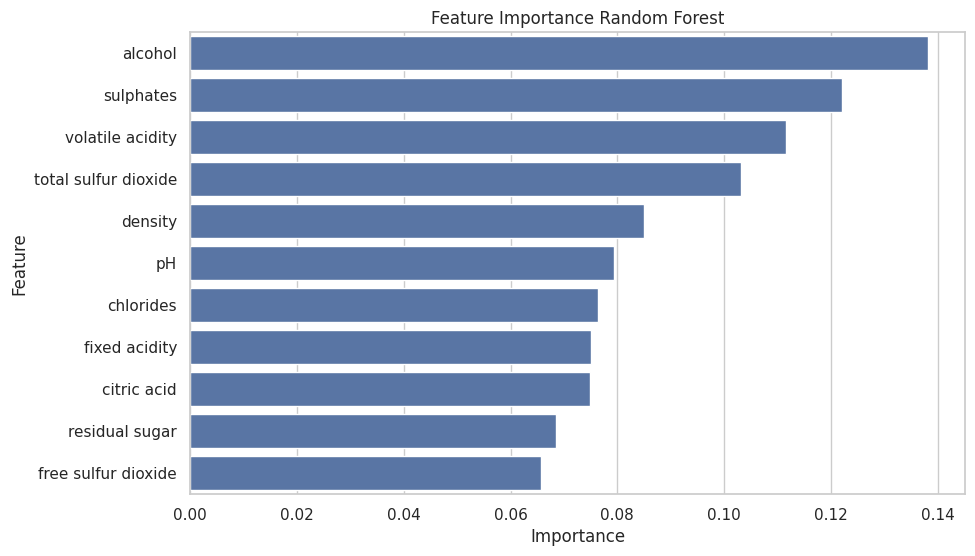

,feature,importance
10,alcohol,0.138230
9,sulphates,0.122101
1,volatile acidity,0.111581
6,total sulfur dioxide,0.103166
7,density,0.085063
8,pH,0.079332
4,chlorides,0.076376
0,fixed acidity,0.074998
2,citric acid,0.074906
3,residual sugar,0.068532


In [113]:
# Feature importance dari model validasi
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

feature_importance

### Interpretasi Feature Importance

Fitur dengan nilai importance lebih tinggi memiliki kontribusi lebih besar dalam proses pemisahan kelas pada Random Forest. Hasil ini dapat digunakan untuk memberikan penjelasan akademik mengenai faktor kimiawi yang paling berpengaruh menurut model. Namun, feature importance bukan bukti kausalitas, melainkan ukuran kontribusi fitur dalam struktur model.

## 14. Training Ulang Model Menggunakan Seluruh Data Training

Setelah model dievaluasi pada data validasi, model dilatih ulang menggunakan seluruh data training. Tujuannya adalah agar model dapat mempelajari seluruh pola yang tersedia sebelum digunakan untuk memprediksi data testing.

> Bagian ini dipertahankan sesuai notebook awal agar hasil prediksi akhir tidak berubah.

In [114]:
# Scaling ulang full data
X_scaled = scaler.fit_transform(X)

# Train full model
model.fit(X_scaled, y)

RandomForestClassifier(random_state=42)

## 15. Preprocessing Data Testing

Sebelum dilakukan prediksi, kolom `Id` pada data testing disimpan terlebih dahulu karena akan digunakan kembali pada file output. Setelah itu, kolom `Id` dihapus dari fitur testing, lalu data testing ditransformasikan menggunakan scaler yang telah disesuaikan pada seluruh data training.

In [115]:
test_id = test['Id']  # simpan id

X_test = test.drop('Id', axis=1)

# scaling
X_test = scaler.transform(X_test)

## 16. Prediksi Data Testing

Model Random Forest yang telah dilatih ulang menggunakan seluruh data training digunakan untuk memprediksi kelas `quality` pada data testing.

In [116]:
test_pred = model.predict(X_test)

## 17. Penyimpanan Hasil Prediksi

Hasil prediksi disimpan ke dalam file CSV dengan dua kolom, yaitu `Id` dan `quality`. Format ini mengikuti kebutuhan pengumpulan hasil prediksi.

> Nama file output tetap dipertahankan sebagai `hasilprediksi_002.csv` agar tidak mengubah hasil akhir dari notebook awal.

In [117]:
output = pd.DataFrame({
    'Id': test_id,
    'quality': test_pred})

output.to_csv('hasilprediksi_002.csv', index=False)

In [118]:
# Menampilkan hasil prediksi
prediksi = pd.read_csv('hasilprediksi_002.csv')
prediksi

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,5


In [119]:
# Validasi format output
print("Kolom output:", prediksi.columns.tolist())
print("Ukuran output:", prediksi.shape)
print("\nJumlah nilai prediksi per kelas:")
print(prediksi['quality'].value_counts().sort_index())

Kolom output: ['Id', 'quality']
Ukuran output: (286, 2)

Jumlah nilai prediksi per kelas:
quality
5    129
6    128
7     29
Name: count, dtype: int64


## 18. Kesimpulan

Berdasarkan keseluruhan proses analisis, model klasifikasi berhasil dibangun untuk memprediksi kualitas wine menggunakan algoritma Random Forest. Tahapan yang dilakukan meliputi eksplorasi data, pemeriksaan missing value, visualisasi distribusi target, analisis korelasi, feature scaling, pelatihan model, evaluasi performa, serta prediksi pada data testing.

Hasil evaluasi pada data validasi digunakan untuk melihat kemampuan model dalam mengenali pola kualitas wine. Confusion matrix dan classification report menunjukkan bahwa model cenderung lebih baik dalam memprediksi kelas dengan jumlah data lebih banyak, sementara kelas dengan jumlah data sedikit lebih sulit diprediksi secara akurat. Hal ini wajar pada dataset dengan distribusi target yang tidak seimbang.

Setelah evaluasi, model dilatih ulang menggunakan seluruh data training agar dapat memanfaatkan seluruh informasi yang tersedia. Model akhir kemudian digunakan untuk menghasilkan prediksi pada data testing dan menyimpannya dalam file `hasilprediksi_027.csv`.

Secara akademik, pendekatan ini sudah mencakup proses utama dalam data mining, yaitu pemahaman data, preprocessing, pembangunan model, evaluasi, interpretasi, dan penyajian hasil prediksi.